# PIPE LINE 2

In [1]:
import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, MiniBatchKMeans
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.decomposition import PCA


In [2]:
def get_list(x):
    if isinstance(x, list):
        names = [i['name'] for i in x]
        if len(names) > 3:
            names = names[:3]
        return names
    if isinstance(x, str):
        try:
            data = literal_eval(x)
            if isinstance(data, list):
                names = [i['name'] for i in data]
                if len(names) > 3:
                    names = names[:3]
                return names
        except (ValueError, SyntaxError):
            return []
    return []

def get_director(x):
    try:
        if isinstance(x, str):
            x = literal_eval(x)
        for i in x:
            if i['job'] == 'Director':
                return i['name']
        return np.nan
    except:
        return np.nan

def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            return ''

def create_eat(x):
    keywords = ' '.join(x['keywords'])
    cast = ' '.join(x['cast'])
    genres = ' '.join(x['genres'])
    director = str(x['director']) if pd.notna(x['director']) and x['director'] != '' else ''
    overview = str(x['overview']) if pd.notna(x['overview']) else ''
    tagline = str(x['tagline']) if pd.notna(x['tagline']) else ''
    return f"{keywords} {cast} {director} {genres} {overview} {tagline}"

In [3]:
credits=pd.read_csv(r".\lesson36_data\credits.csv")
keywords=pd.read_csv(r".\lesson36_data\keywords.csv")
links=pd.read_csv(r".\lesson36_data\links.csv")
movies=pd.read_csv(r".\lesson36_data\movies_metadata.csv")

C:\Users\Kirill\AppData\Local\Temp\ipykernel_10148\1776525590.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv(r".\lesson36_data\movies_metadata.csv")


In [4]:
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
credits['id'] = pd.to_numeric(credits['id'], errors='coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors='coerce')
links['tmdbId'] = pd.to_numeric(links['tmdbId'], errors='coerce')

In [5]:
movies = movies.dropna(subset=['id'])
links = links.dropna(subset=['tmdbId'])

In [6]:
movies['id'] = movies['id'].astype(int)
credits['id'] = credits['id'].astype(int)
keywords['id'] = keywords['id'].astype(int)
links['tmdbId'] = links['tmdbId'].astype(int)

In [7]:
print(f"before: {movies.shape[0]}")
movies = movies.drop_duplicates(subset='id')
print(f"after: {movies.shape[0]}")

before: 45463
after: 45433


In [8]:
print(f"SHAPES: movies -{movies.shape} ,credits-{credits.shape} ,keywords-{keywords.shape} ,links-{links.shape}")

SHAPES: movies -(45433, 24) ,credits-(45476, 3) ,keywords-(46419, 2) ,links-(45624, 3)


In [9]:
df = movies.merge(credits, on='id', how='left')
df = df.merge(keywords, on='id', how='left')
df = df.merge(links, left_on='id', right_on='tmdbId', how='left')
df.shape

(46629, 30)

In [10]:
cols_to_keep = [
    'id',
    'original_title',
    'overview',
    'tagline',
    'genres',
    'cast',
    'crew',
    'keywords',
    'popularity',
    'vote_average',
    'release_date',
    'imdbId',
    'tmdbId'
]
df = df[[c for c in cols_to_keep if c in df.columns]]
df = df.reset_index(drop=True)
df.head(3)

,id,original_title,overview,tagline,genres,cast,crew,keywords,popularity,vote_average,release_date,imdbId,tmdbId
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...",NaN,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",21.946943,7.7,1995-10-30,114709,862
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",17.015539,6.9,1995-12-15,113497,8844
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392...",11.7129,6.5,1995-12-22,113228,15602


In [11]:
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    df[feature] = df[feature].fillna('[]')
df['director'] = df['crew'].apply(get_director)
df['cast'] = df['cast'].apply(get_list)
df['keywords'] = df['keywords'].apply(get_list)
df['genres'] = df['genres'].apply(get_list)
features_to_clean = ['cast', 'keywords', 'director', 'genres']
for feature in features_to_clean:
    df[feature] = df[feature].apply(clean_data)
df = df.drop('crew', axis=1)
df[['original_title', 'cast', 'director', 'genres']].head(3)

,original_title,cast,director,genres
0,Toy Story,"[tomhanks, timallen, donrickles]",johnlasseter,"[animation, comedy, family]"
1,Jumanji,"[robinwilliams, jonathanhyde, kirstendunst]",joejohnston,"[adventure, fantasy, family]"
2,Grumpier Old Men,"[waltermatthau, jacklemmon, ann-margret]",howarddeutch,"[romance, comedy]"


In [12]:
df['eat'] = df.apply(create_eat, axis=1)


In [13]:
vec_5 = CountVectorizer(min_df=5)
vec_5.fit(df['eat'])
vocab_5 = set(vec_5.vocabulary_.keys())
vec_25 = CountVectorizer(min_df=25)
vec_25.fit(df['eat'])
vocab_25 = set(vec_25.vocabulary_.keys())
lost_words = list(vocab_5 - vocab_25)
print(f"При min_df=5 у нас слов:  {len(vocab_5)}")
print(f"При min_df=25 у нас слов: {len(vocab_25)}")
if len(lost_words) > 0:
    print(random.sample(lost_words, min(20, len(lost_words))))

При min_df=5 у нас слов:  31125
При min_df=25 у нас слов: 8986
['antisocial', 'carnegie', 'nickofferman', 'prim', 'commerce', 'denis', 'prosper', 'renewal', 'disciplines', 'prays', 'hairstylist', 'enthralling', 'classy', 'pero', 'shiki', 'kurtneumann', 'edwardjamesolmos', 'viewed', 'michaelverhoeven', 'dunne']


In [14]:
tfidf = TfidfVectorizer(stop_words='english', min_df=5, max_features=31125)
tfidf_matrix = tfidf.fit_transform(df['eat'])

In [15]:
n_components = 400
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_matrix = svd.fit_transform(tfidf_matrix)
explained_variance = svd.explained_variance_ratio_.sum()
print (explained_variance)

0.18613390219883533


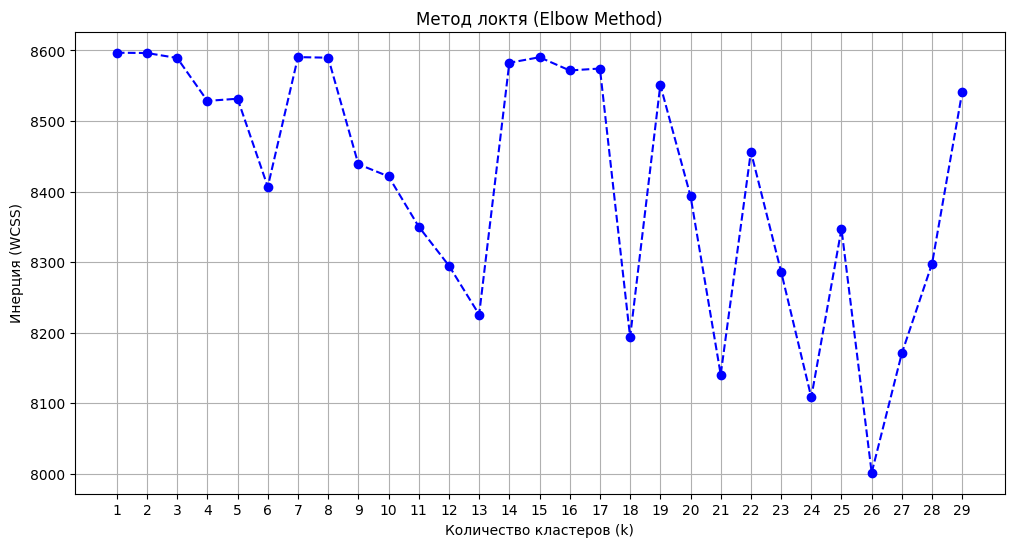

In [16]:
wcss = []
k_range = range(1, 30, 1)
for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10, batch_size=2048)
    kmeans.fit(latent_matrix)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(12, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Метод локтя (Elbow Method)')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (WCSS)')
plt.xticks(k_range)
plt.grid(True)


In [17]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(latent_matrix)
print("Размер топ самых крупных кластеров:")
print(df['cluster'].value_counts().head(10))


Размер топ самых крупных кластеров:
cluster
4    19607
2     9912
5     6527
1     4518
0     3765
3     2300
Name: count, dtype: int64


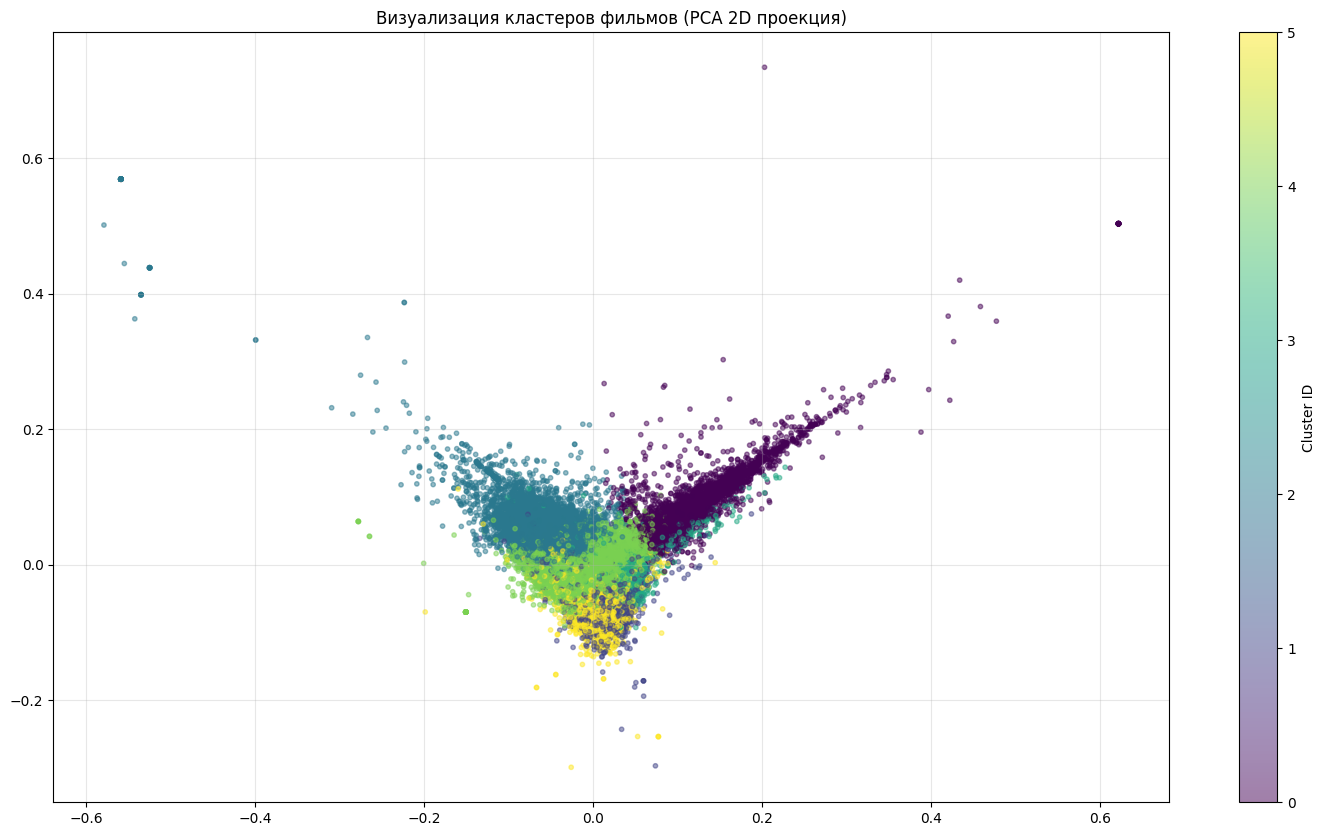

In [18]:
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(latent_matrix)
df['x'] = coords_2d[:, 0]
df['y'] = coords_2d[:, 1]
plt.figure(figsize=(18, 10))
plt.scatter(df['x'], df['y'], c=df['cluster'], cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Cluster ID')
plt.title('Визуализация кластеров фильмов (PCA 2D проекция)')
plt.grid(True, alpha=0.3)


C:\Users\Kirill\AppData\Local\Temp\ipykernel_10148\2840959156.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, order=cluster_counts.index, palette='viridis')


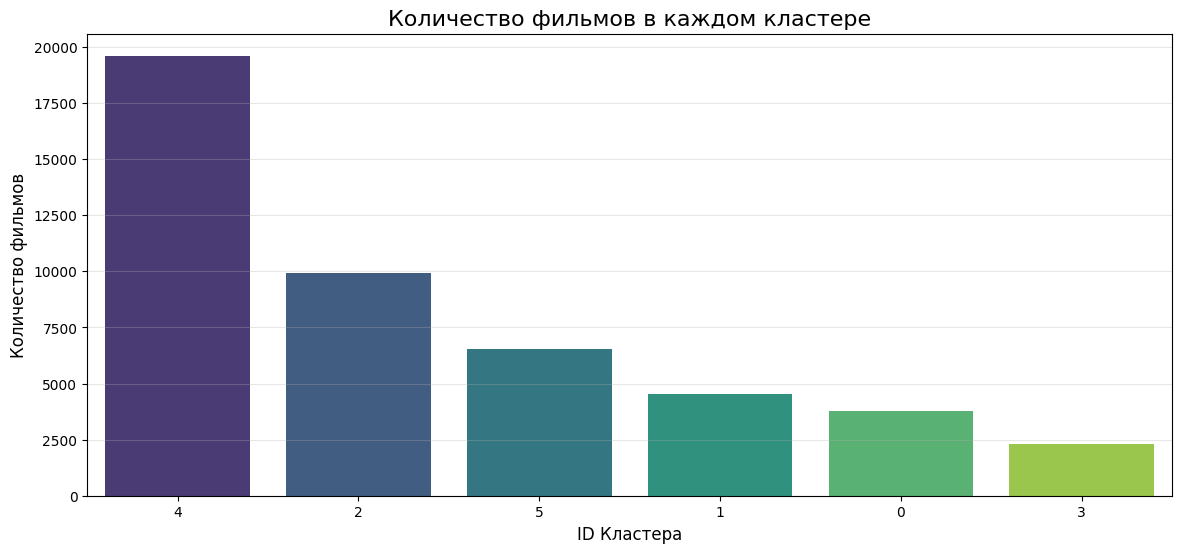

In [19]:
cluster_counts = df['cluster'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, order=cluster_counts.index, palette='viridis')
plt.title('Количество фильмов в каждом кластере', fontsize=16)
plt.xlabel('ID Кластера', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
